In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [2]:
image_path ="../output_videos/cropped_image.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

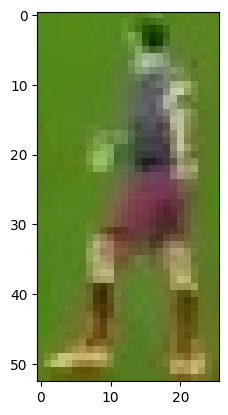

In [3]:
plt.imshow(image)
plt.show()

# Take the top halp of the image

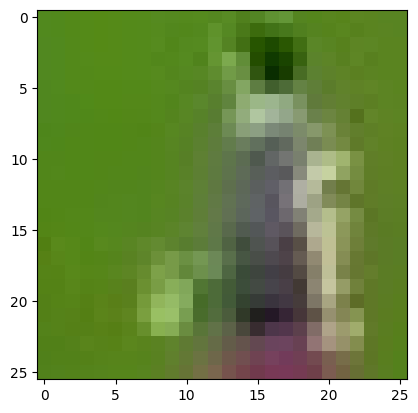

In [9]:
top_half_image = image[0 : int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

# Cluster the image into two clusters

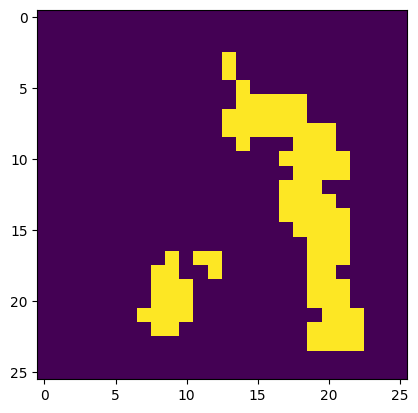

In [25]:
# Reshape the image into 2d array
image_2d = top_half_image.reshape(-1, 3)

# Perform k-means clustering
kmeans = KMeans(n_clusters=2, random_state=0).fit(image_2d)

# Get the cluster centers (dominant colors)
labels = kmeans.labels_

# Reshape the labels back to the original image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# Display the clustered image
plt.imshow(clustered_image)
plt.show()

In [14]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
player_cluster = 1 - non_player_cluster
print(f"Non-player cluster: {non_player_cluster}")
print(f"Player cluster: {player_cluster}")

Non-player cluster: 0
Player cluster: 1


In [15]:
kmeans.cluster_centers_[player_cluster]

array([142.68085106, 156.88297872, 110.80851064])